# Taller 06: Reduccion de dimensiones

Aplicacion de PCA, MDS clasico, MDS metrico, MDS no metrico y UMAP al dataset WISDM. Se analizan los cuatro sensores por separado para los voluntarios seleccionados y luego de forma combinada.


In [1]:
%pip install -q umap-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import arff

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.metrics import pairwise_distances

import umap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Dataset

Los archivos ARFF deben estar en `data/arff_files/`, organizados por dispositivo y sensor.

In [12]:
ARFF_ROOT = Path("..") / "data" / "arff_files"

if ARFF_ROOT.exists():
    print(f"Datos encontrados en: {ARFF_ROOT.resolve()}")
else:
    print(
        f"ADVERTENCIA: no se encontro {ARFF_ROOT}. "
        "Extrae alli la carpeta arff_files del dataset WISDM antes de continuar."
    )

Datos encontrados en: C:\Users\luis9\OneDrive\Documentos\1.Universidad\Programación\Talleres_Grupo3_IA\data\arff_files


## Voluntarios

In [13]:
SELECTED_IDS = [1607, 1623, 1641]
print("Voluntarios seleccionados:", SELECTED_IDS)

Voluntarios seleccionados: [1607, 1623, 1641]


## Carga de datos

Se usan las 30 columnas xyzbins y `ACTIVITY`.

In [14]:
CASES = {
    "phone-accel": ARFF_ROOT / "phone" / "accel",
    "phone-gyro": ARFF_ROOT / "phone" / "gyro",
    "watch-accel": ARFF_ROOT / "watch" / "accel",
    "watch-gyro": ARFF_ROOT / "watch" / "gyro",
}

XYZ_COLS = [f"{axis}{i}" for axis in ["X", "Y", "Z"] for i in range(10)]


def expected_filepath(subject_id: int, case: str) -> Path:
    device, sensor = case.split("-")
    return CASES[case] / f"data_{subject_id}_{sensor}_{device}.arff"


missing_files = [
    expected_filepath(subject_id, case)
    for subject_id in SELECTED_IDS
    for case in CASES
    if not expected_filepath(subject_id, case).exists()
]
if missing_files:
    raise FileNotFoundError(
        "Faltan archivos ARFF. Primeros faltantes: "
        + ", ".join(str(path) for path in missing_files[:5])
    )


def load_arff_case(subject_id: int, case: str) -> pd.DataFrame:
    """Carga xyzbins y ACTIVITY para un voluntario y un caso."""
    filepath = expected_filepath(subject_id, case)
    data, _ = arff.loadarff(filepath)
    df = pd.DataFrame(data)
    df.columns = [column.strip('"') for column in df.columns]
    df["ACTIVITY"] = df["ACTIVITY"].apply(
        lambda value: value.decode("utf-8") if isinstance(value, bytes) else value
    )
    df = df[XYZ_COLS + ["ACTIVITY"]].copy()
    df["SUBJECT"] = subject_id
    return df


def get_matrix(df: pd.DataFrame):
    """Extrae la matriz de features y el ground truth."""
    X = df[XYZ_COLS].to_numpy(dtype=float)
    y = df["ACTIVITY"].to_numpy()
    return X, y

## Reduccion

In [15]:
def reduce_pca(X, random_state=RANDOM_STATE):
    return PCA(n_components=2, random_state=random_state).fit_transform(X)


def reduce_classical_mds(X):
    """MDS clasico mediante PCoA y doble centrado."""
    D = pairwise_distances(X, metric="euclidean")
    D2 = D ** 2
    n = D.shape[0]
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J

    eigvals, eigvecs = np.linalg.eigh(B)
    order = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    positive = eigvals > 1e-10
    p = min(2, positive.sum())
    L = np.diag(np.sqrt(eigvals[positive][:p]))
    V = eigvecs[:, positive][:, :p]
    coords = V @ L
    if coords.shape[1] < 2:
        coords = np.hstack([coords, np.zeros((coords.shape[0], 2 - coords.shape[1]))])
    return coords


def reduce_mds_metric(X, random_state=RANDOM_STATE):
    return MDS(n_components=2, metric=True, n_init=2, max_iter=300,
               random_state=random_state, normalized_stress=False).fit_transform(X)


def reduce_mds_nonmetric(X, random_state=RANDOM_STATE):
    return MDS(n_components=2, metric=False, n_init=2, max_iter=300,
               random_state=random_state, normalized_stress=False).fit_transform(X)


def reduce_umap(X, random_state=RANDOM_STATE):
    return umap.UMAP(n_components=2, random_state=random_state).fit_transform(X)


TECHNIQUES = {
    "PCA": reduce_pca,
    "MDS Clasico": reduce_classical_mds,
    "MDS Metrico": reduce_mds_metric,
    "MDS No-metrico": reduce_mds_nonmetric,
    "UMAP": reduce_umap,
}

## Graficas

In [16]:
MAX_SAMPLES = 800


def plot_techniques(X, y, title: str):
    """Reduce y grafica los datos en cinco paneles comparables."""
    Xs = StandardScaler().fit_transform(X)
    if len(Xs) > MAX_SAMPLES:
        rng = np.random.default_rng(RANDOM_STATE)
        indices = rng.choice(len(Xs), size=MAX_SAMPLES, replace=False)
        Xs, y = Xs[indices], y[indices]

    activities = sorted(pd.unique(y))
    cmap = plt.get_cmap("tab20", len(activities))
    color_map = {activity: cmap(index) for index, activity in enumerate(activities)}
    colors = [color_map[activity] for activity in y]

    fig, axes = plt.subplots(1, 5, figsize=(28, 5))
    fig.suptitle(f"{title} (n={len(Xs)})", fontsize=14)

    for axis, (name, function) in zip(axes, TECHNIQUES.items()):
        embedding = function(Xs)
        axis.scatter(embedding[:, 0], embedding[:, 1], c=colors, s=12, alpha=0.8)
        axis.set_title(name)
        axis.set_xlabel("Dim 1")
        axis.set_ylabel("Dim 2")

    handles = [
        plt.Line2D(
            [0], [0], marker="o", color="w", markerfacecolor=color_map[activity],
            markersize=8, label=activity
        )
        for activity in activities
    ]
    fig.legend(handles=handles, title="ACTIVITY", loc="center left", bbox_to_anchor=(1.0, 0.5))
    plt.tight_layout()
    plt.show()

## Analisis individual

C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\A

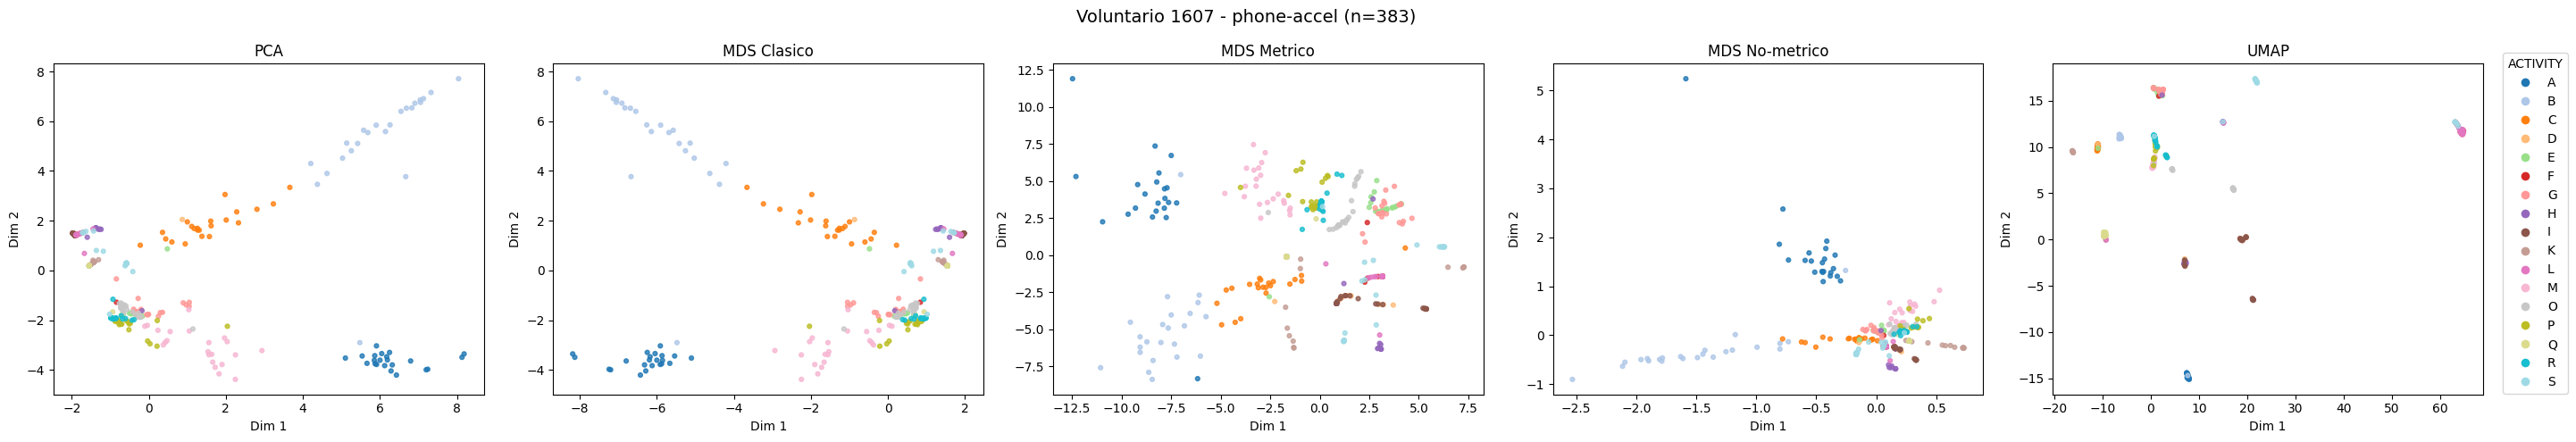

C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\A

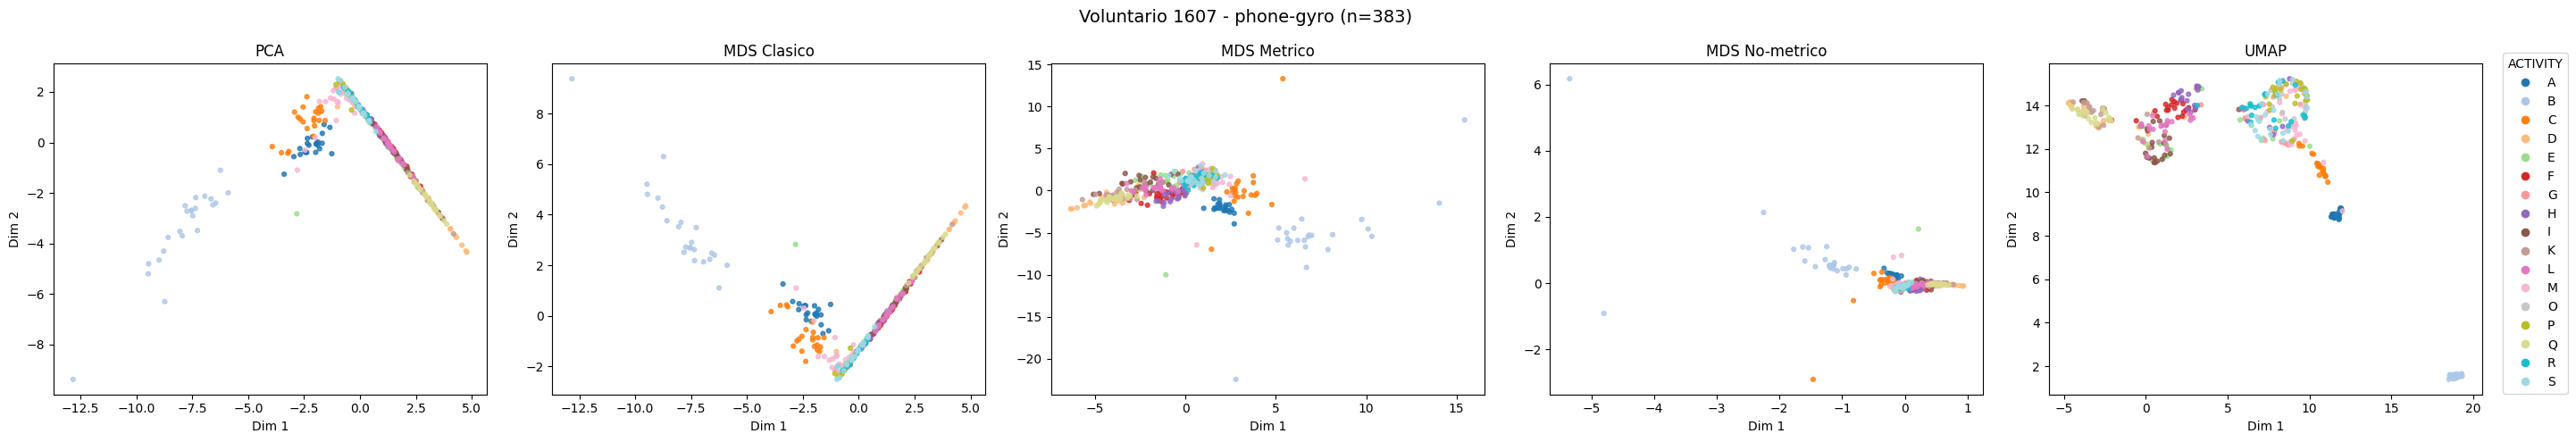

C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\A

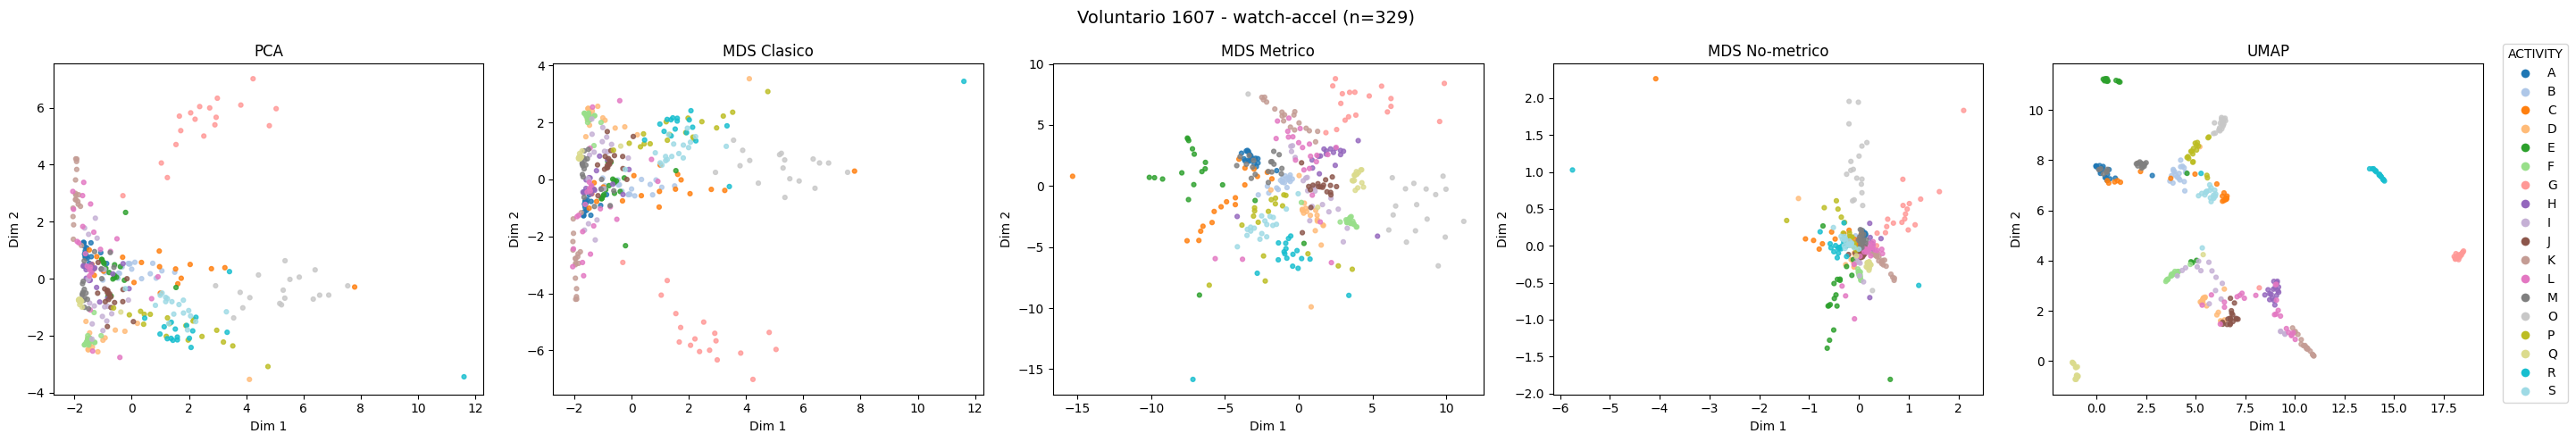

C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\A

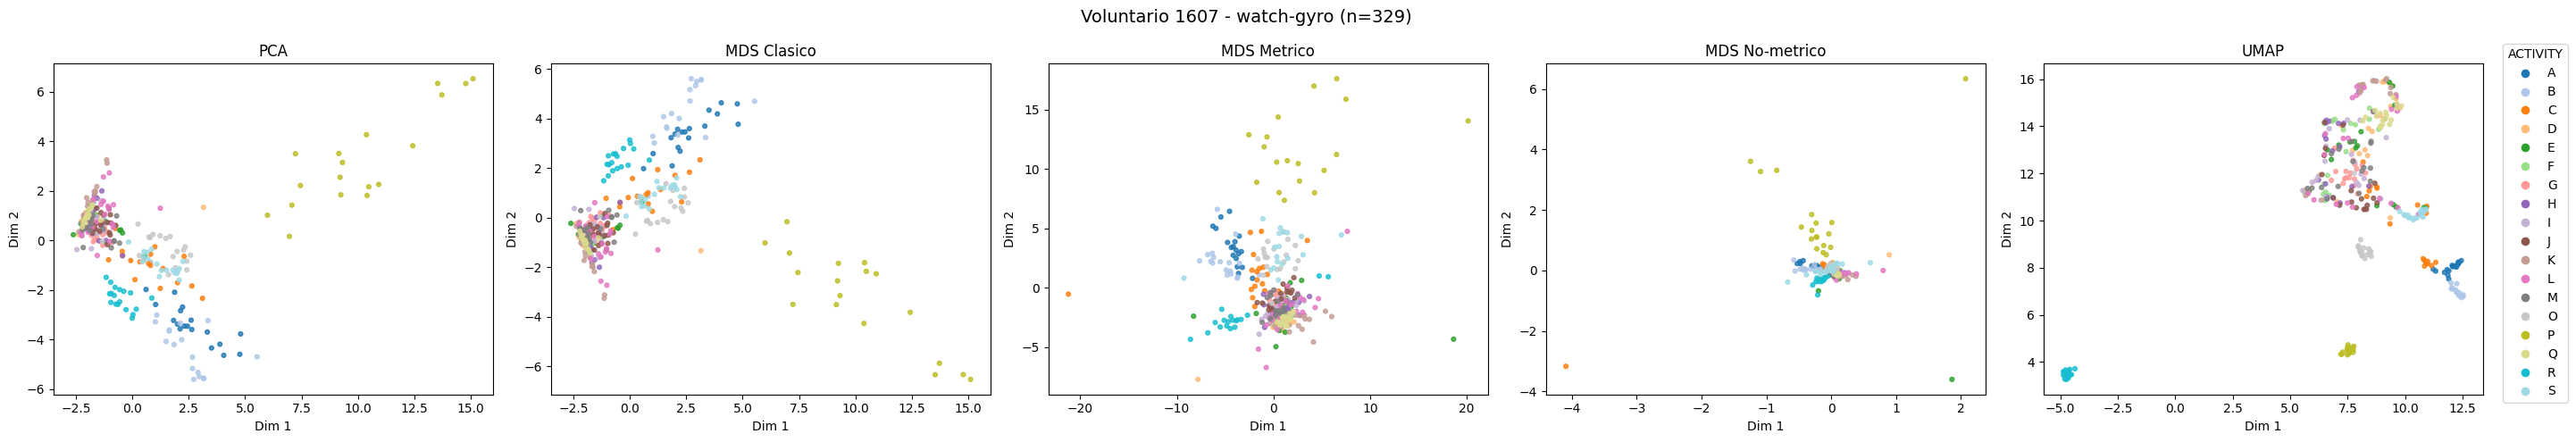

C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\A

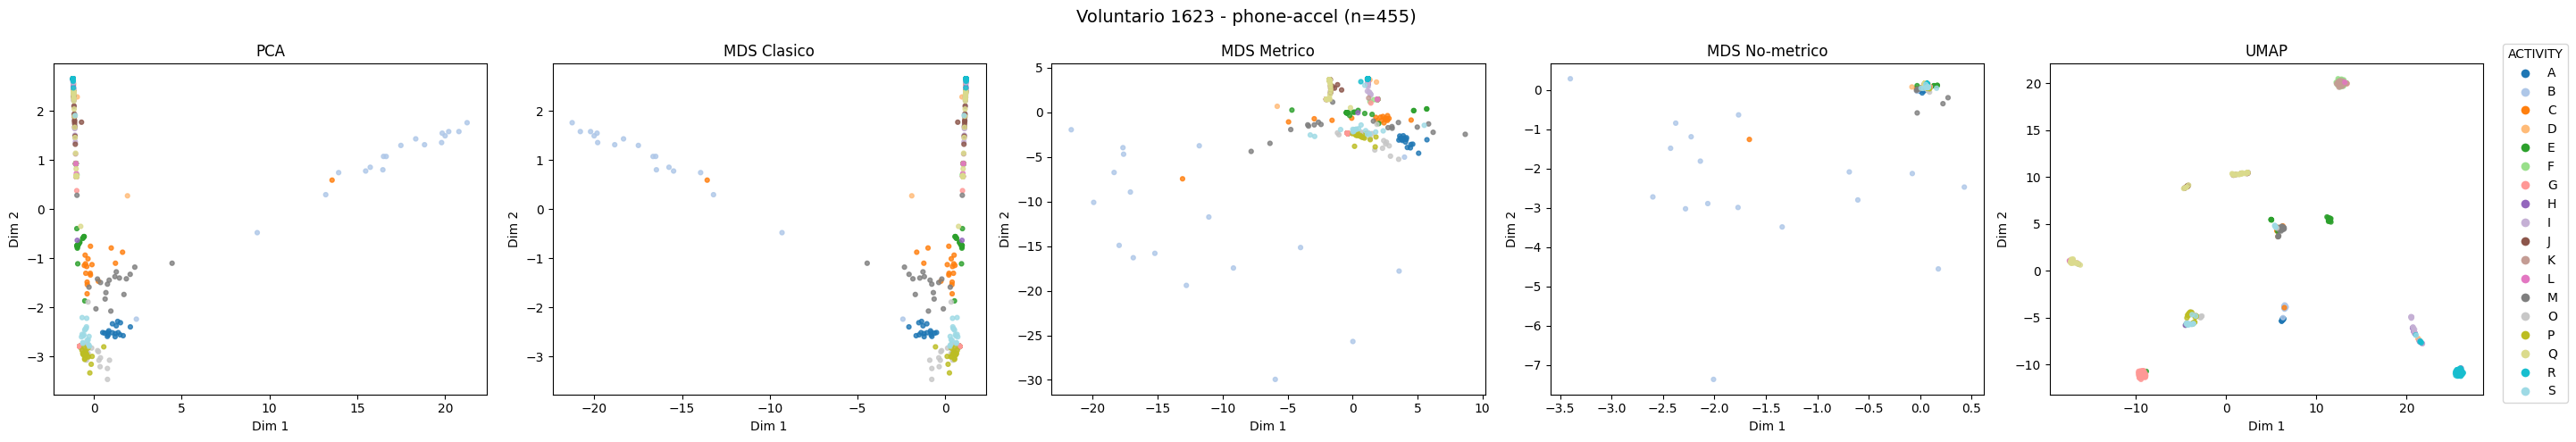

C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\A

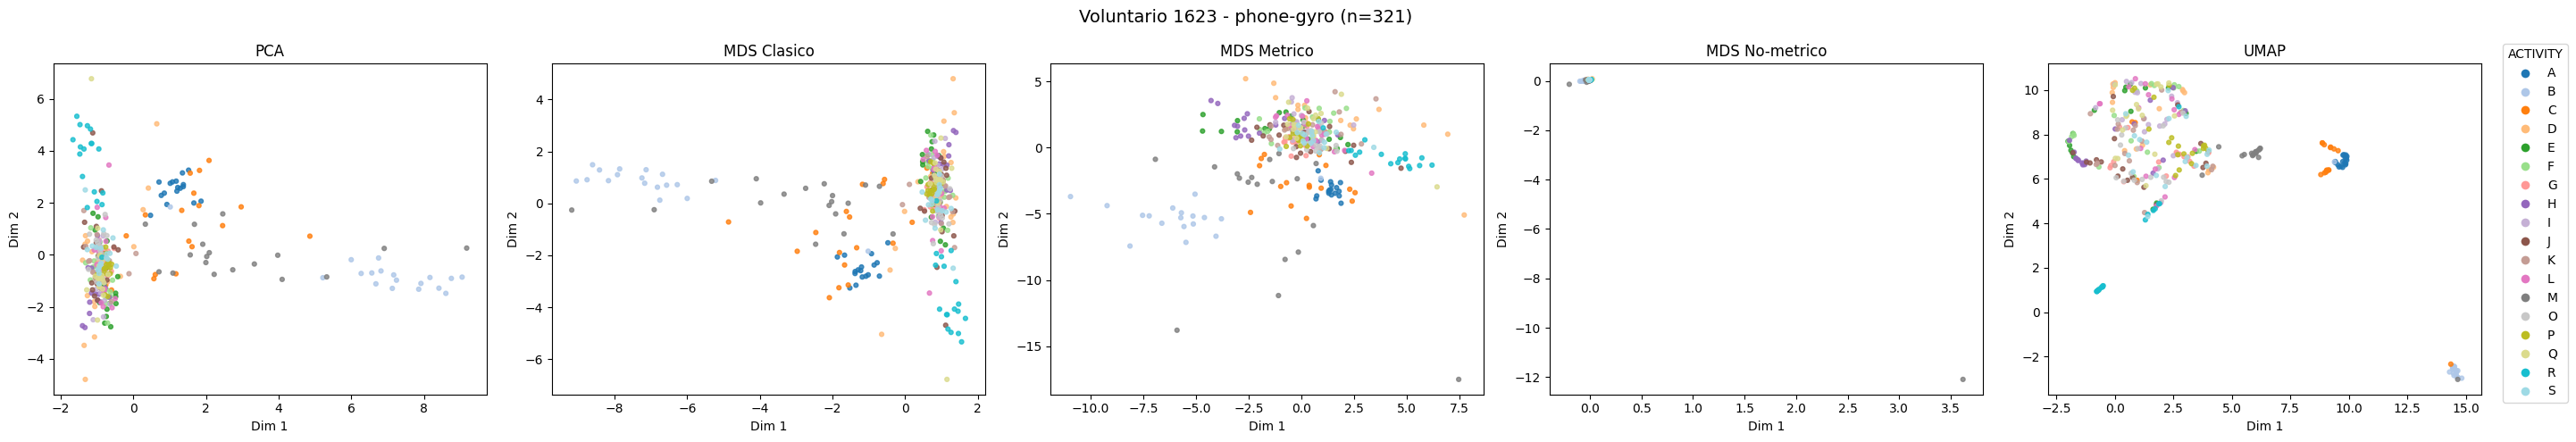

C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\A

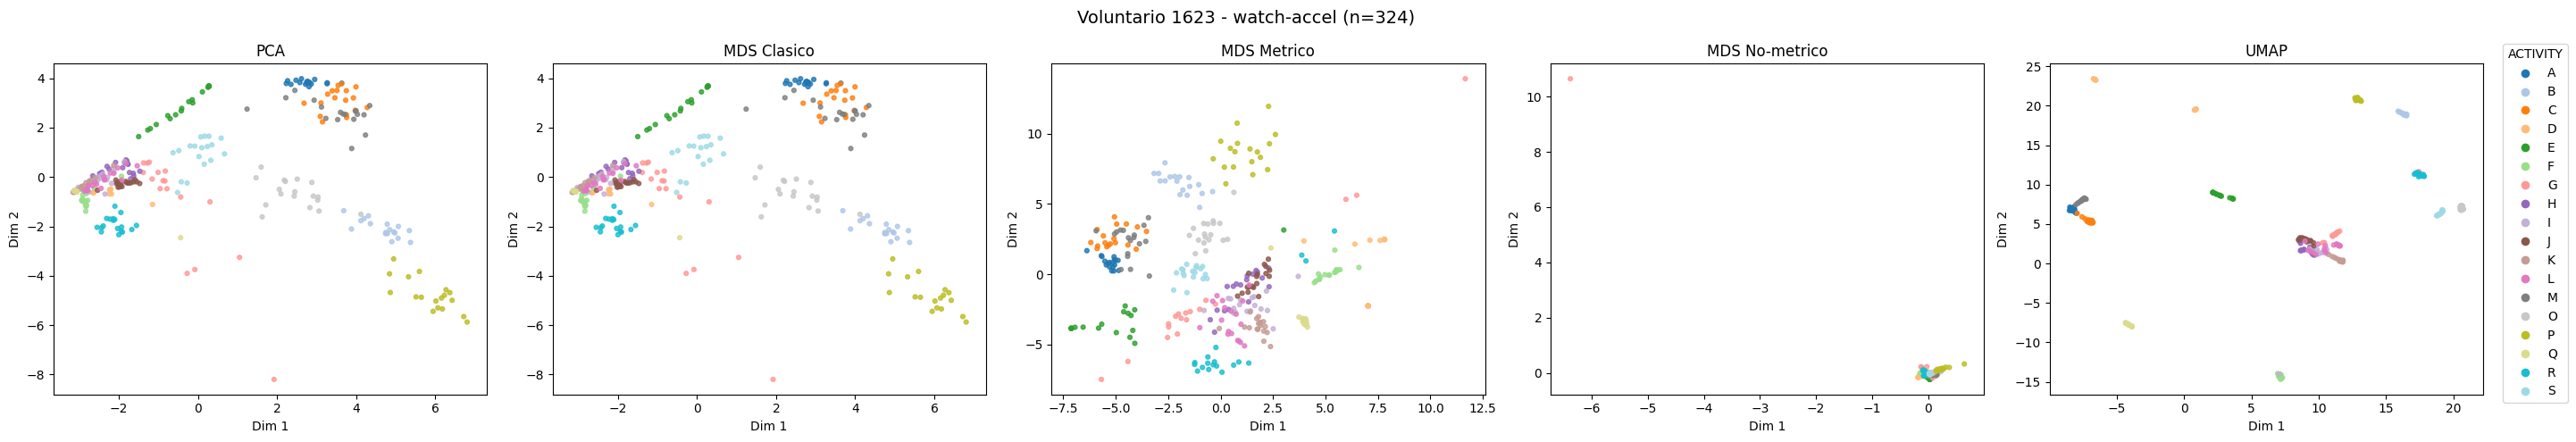

C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\A

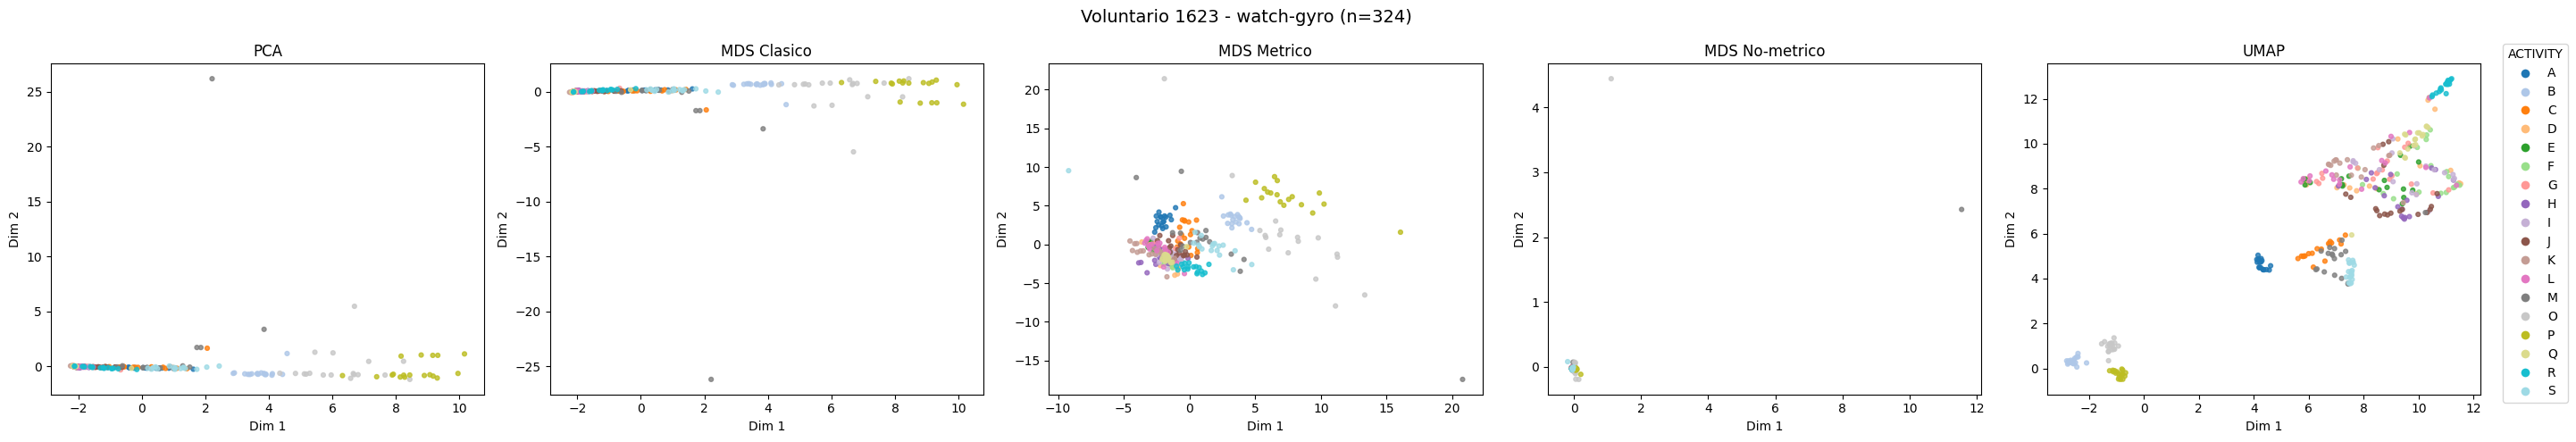

C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\A

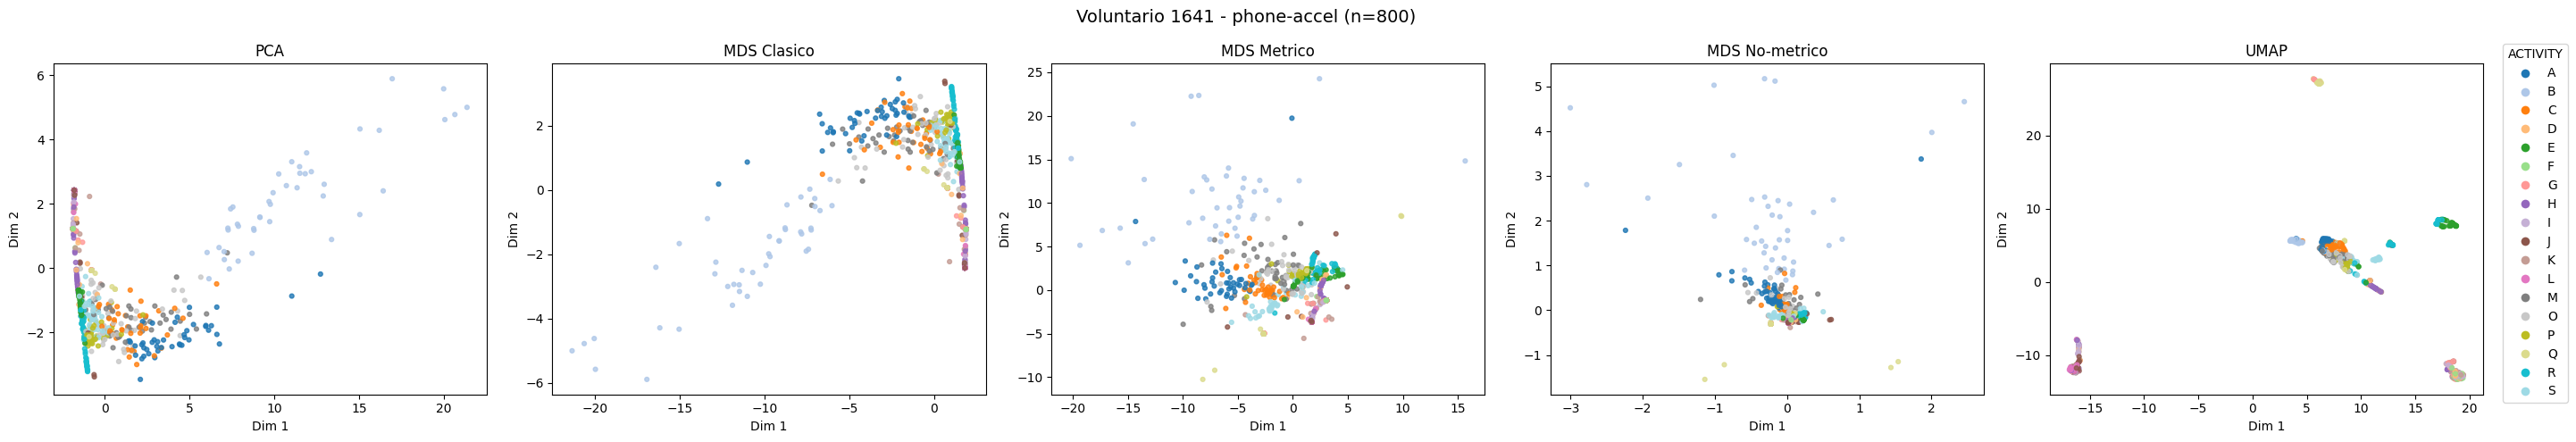

C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\A

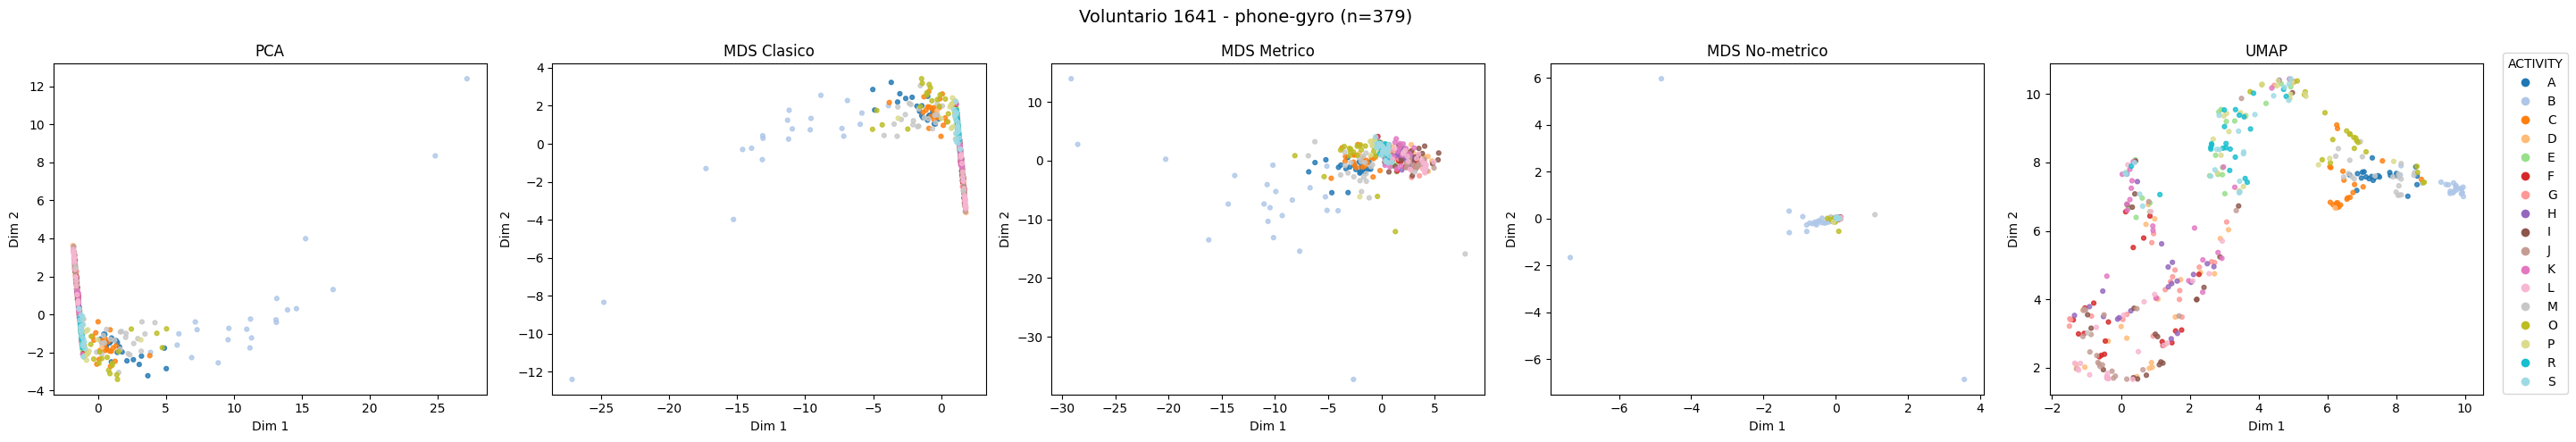

C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\A

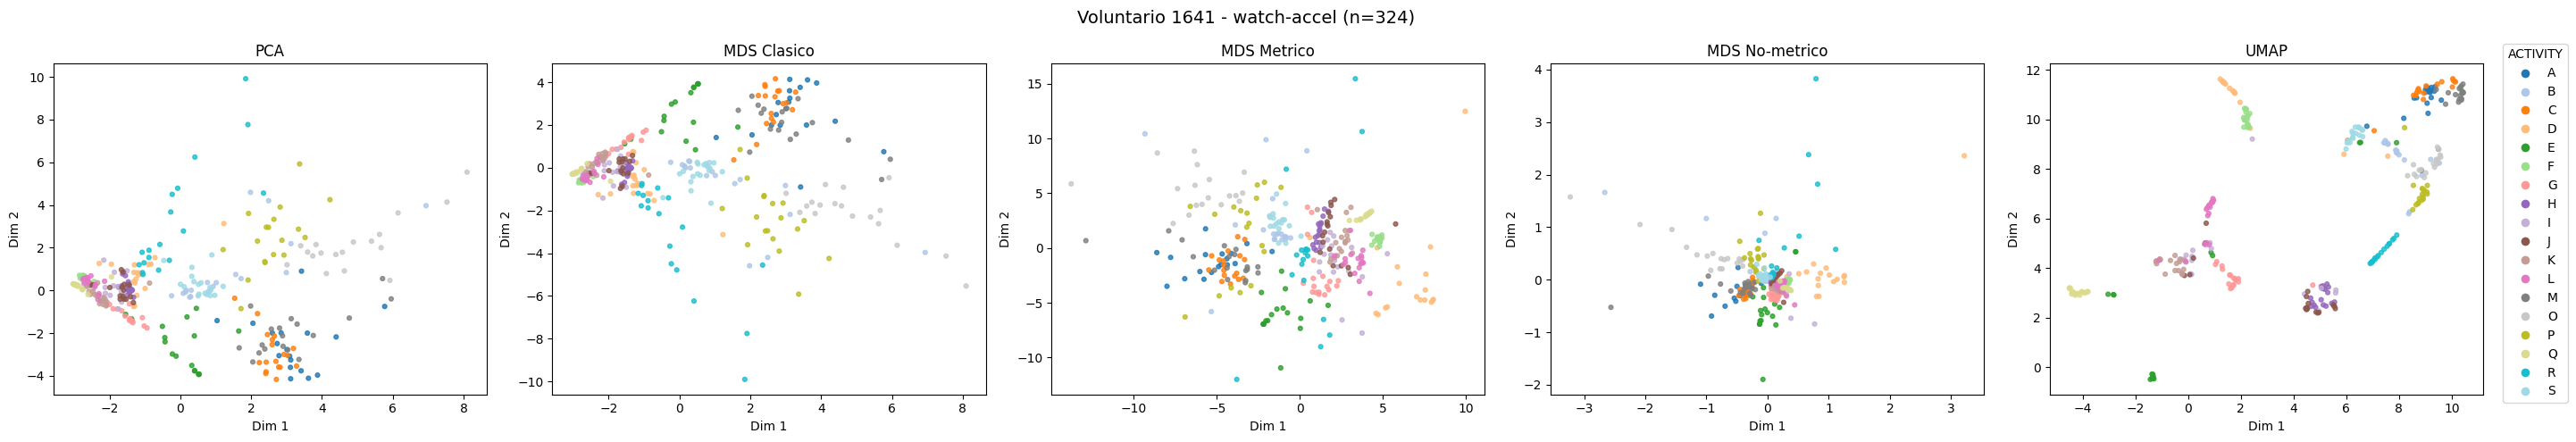

C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\A

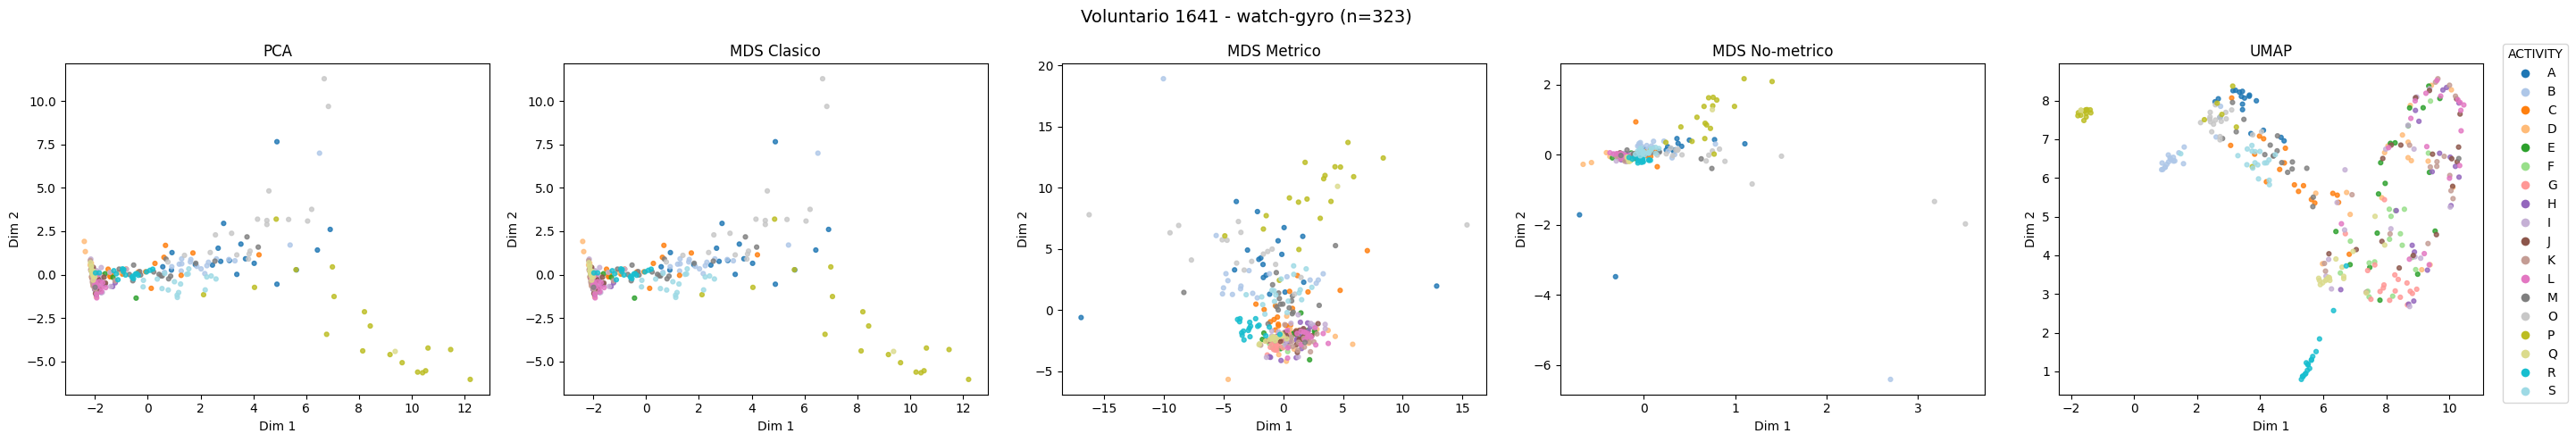

In [17]:
for subject_id in SELECTED_IDS:
    for case in CASES:
        df_case = load_arff_case(subject_id, case)
        X, y = get_matrix(df_case)
        plot_techniques(X, y, title=f"Voluntario {subject_id} - {case}")

## Analisis combinado

C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\A

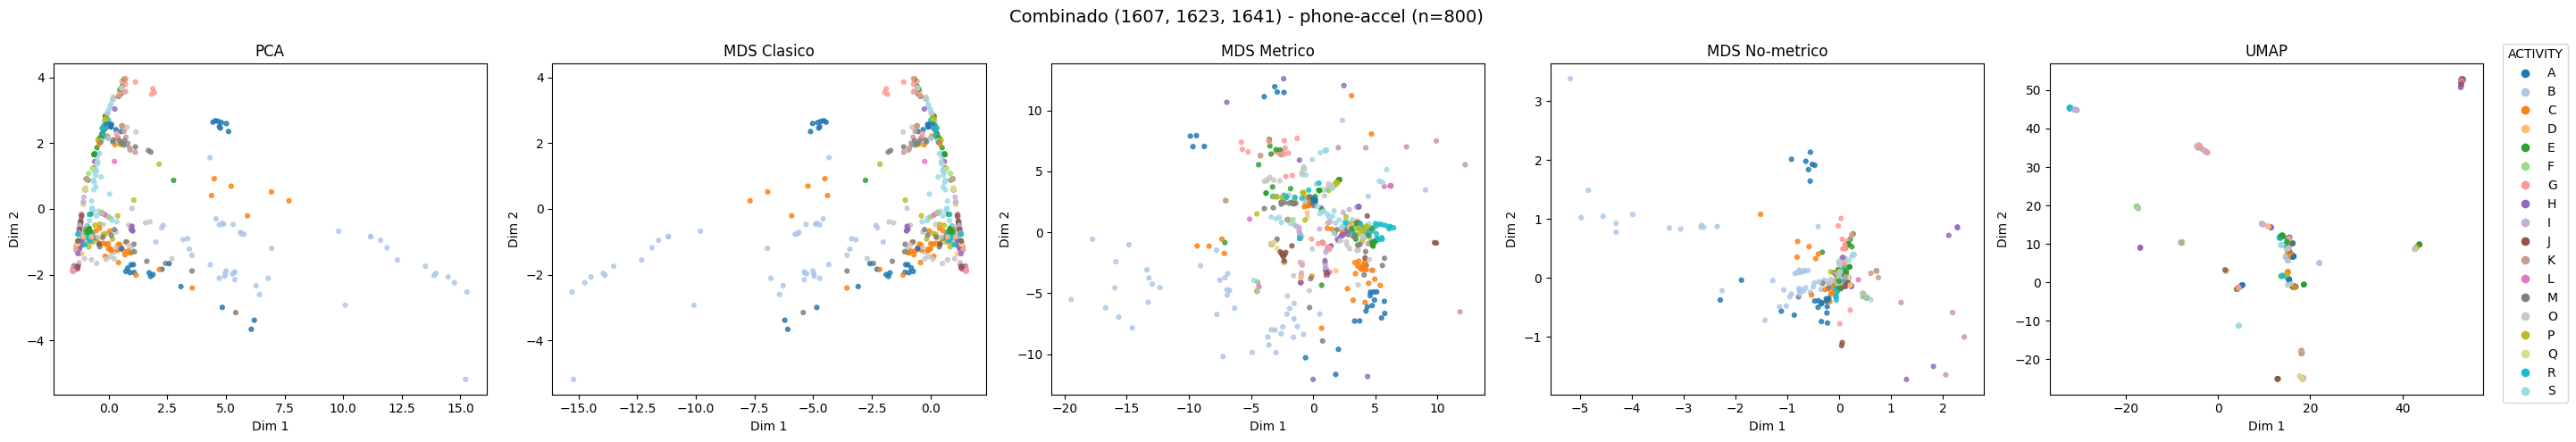

C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\A

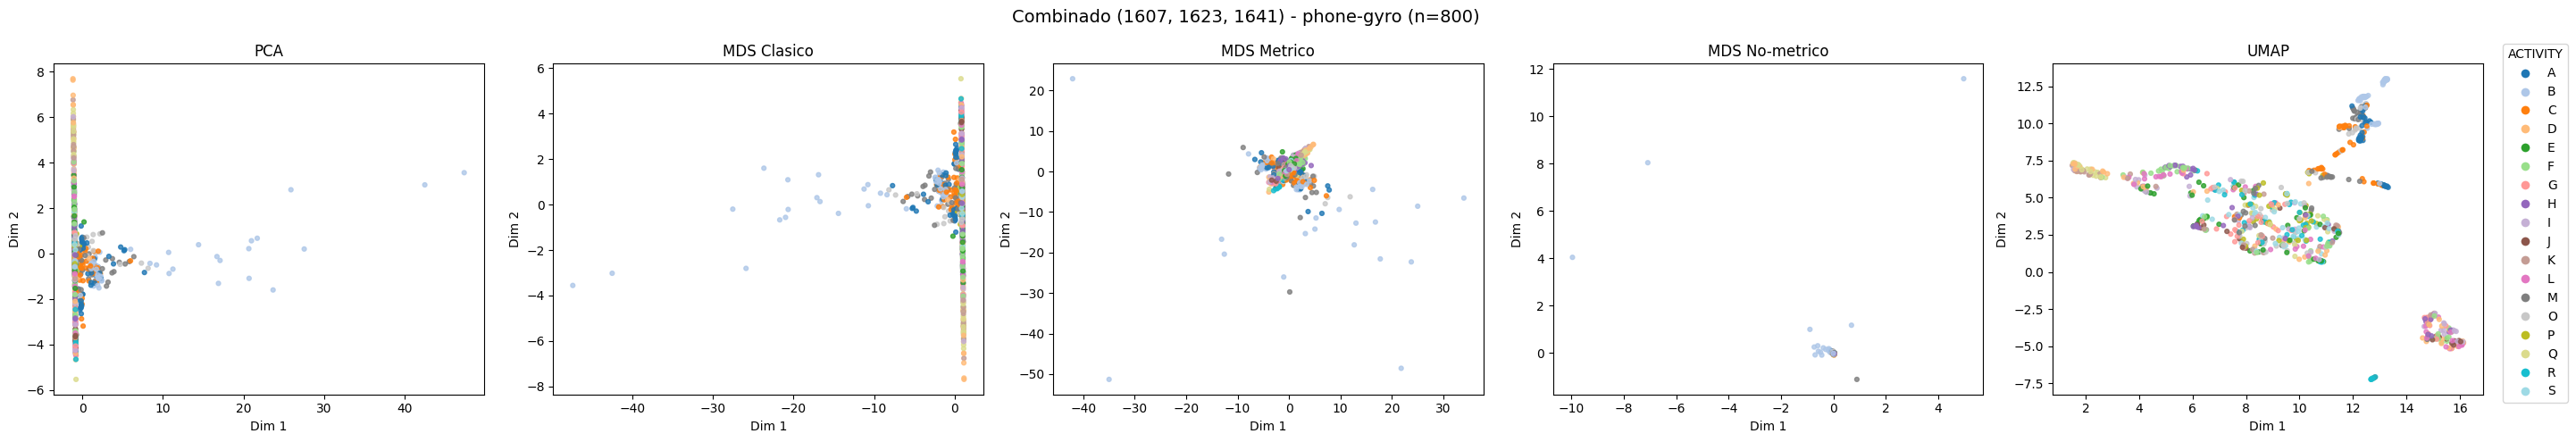

C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\A

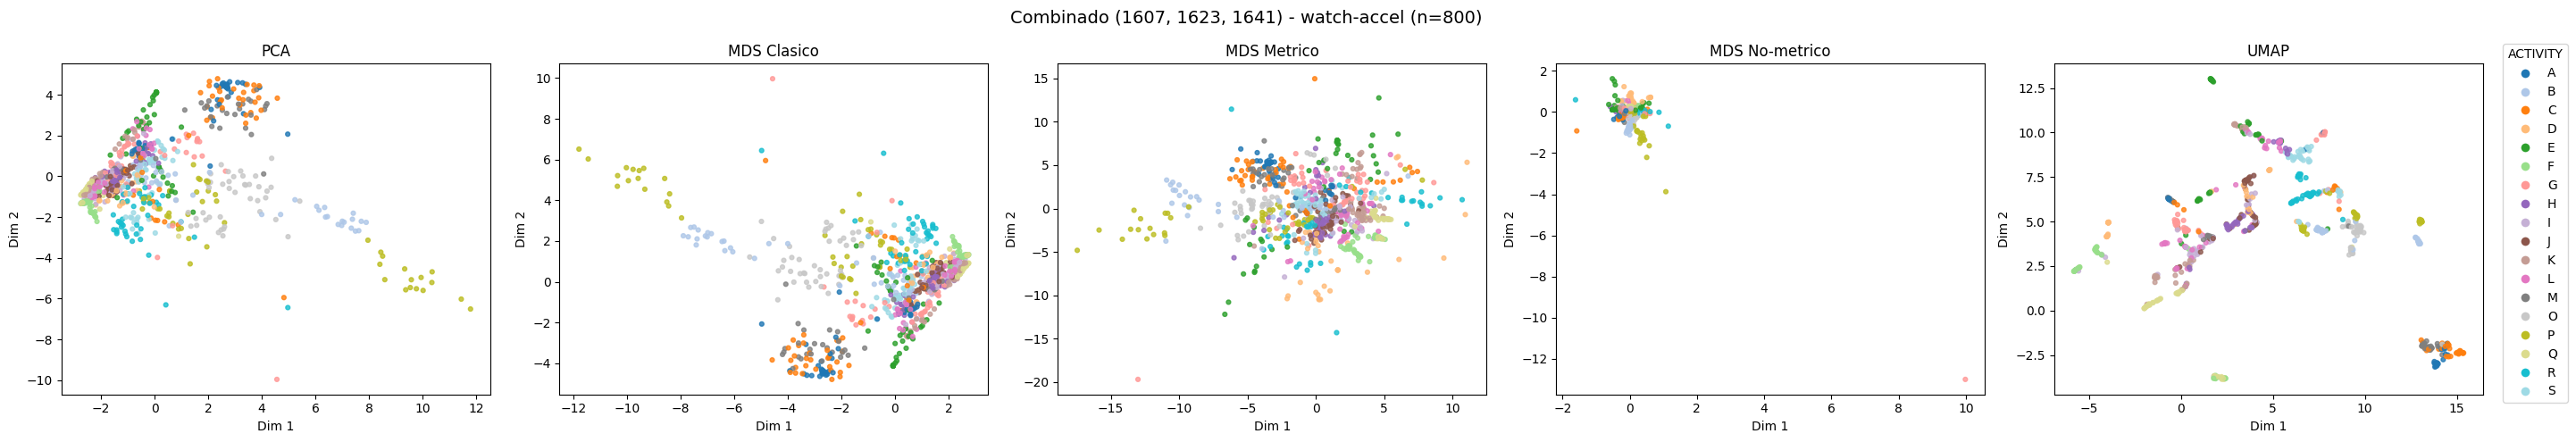

C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\luis9\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_mds.py:760: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
C:\Users\luis9\A

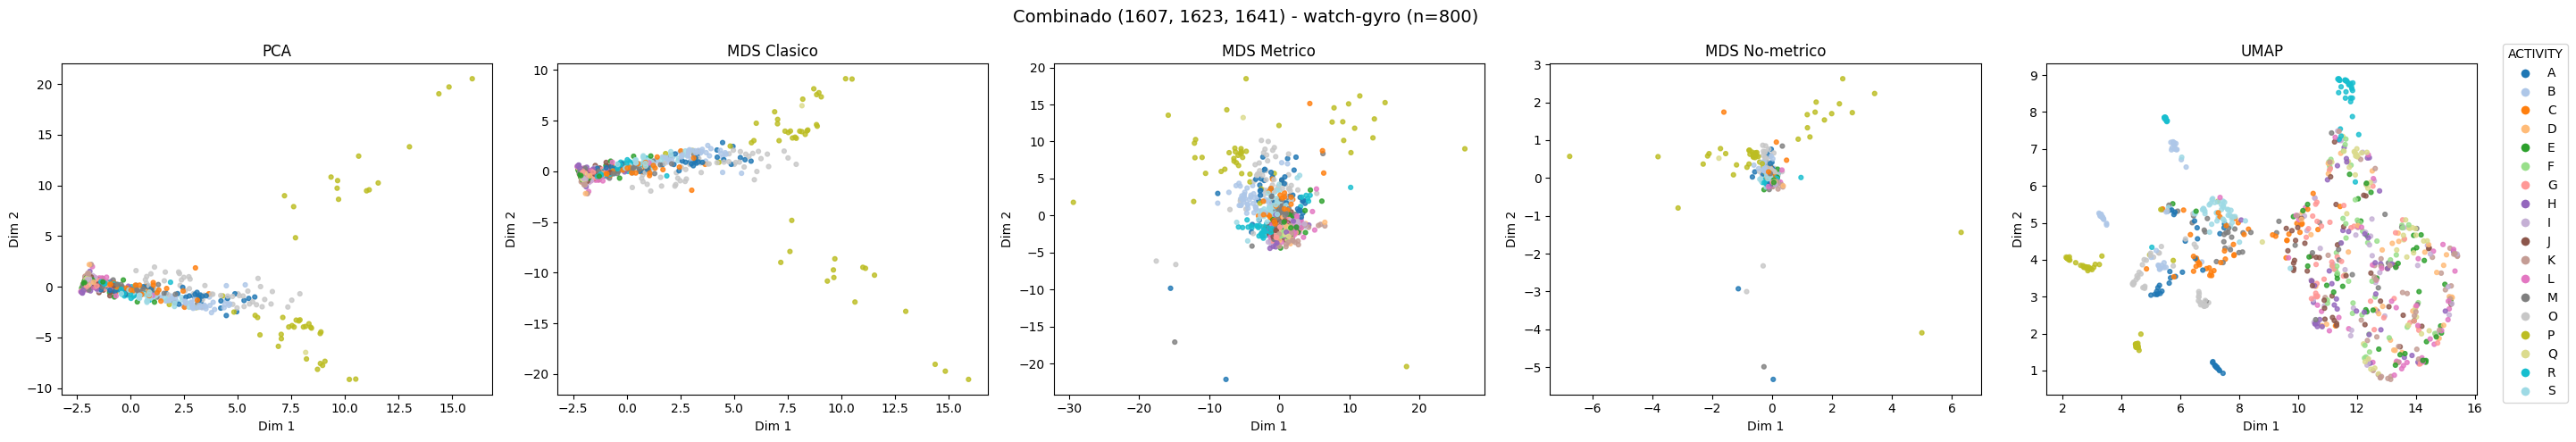

In [18]:
for case in CASES:
    dfs = [load_arff_case(subject_id, case) for subject_id in SELECTED_IDS]
    df_combined = pd.concat(dfs, ignore_index=True)
    X, y = get_matrix(df_combined)
    plot_techniques(X, y, title=f"Combinado ({', '.join(map(str, SELECTED_IDS))}) - {case}")

## Conclusiones

Las actividades con patrones de movimiento mas marcados, como caminar, correr o subir y bajar escaleras, suelen diferenciarse mejor en dos dimensiones porque generan distribuciones mas separadas.

Las actividades con movimientos parecidos o de menor intensidad, como escribir, comer y otras actividades manuales, suelen superponerse con mayor frecuencia.

UMAP suele conservar mejor la estructura local de los grupos. PCA y MDS clasico ofrecen una vista mas global y facil de interpretar, mientras que MDS metrico y no metrico pueden mostrar separaciones diferentes segun las distancias entre las muestras.

Estas observaciones deben contrastarse con los graficos individuales y combinados para indicar las actividades concretas que mejor se separan y las que mas se superponen.